In [1]:
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("q2_customers.csv")
print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Saving q2_customers.csv to q2_customers (1).csv
Dataset loaded successfully
Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
# ============================================================
# Task 1: Data Preparation
# ============================================================

print("=== Dataset Info ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Summary Statistics ===")
print(df.describe().round(2))

# Scale all features using StandardScaler
scaler   = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Convert back to DataFrame for readability
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("\nScaling complete.")
print(f"Scaled data shape: {df_scaled.shape}")
print("\nFirst 3 rows after scaling:")
print(df_scaled.head(3).round(3))



=== Dataset Info ===
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

=== Missing Values ===
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

=== Summary Statistics ===
          age  annual_spend  visits_per_month  basket_size  \
count  500.00        500.00            500.00       500.00   
mean    40.45      48856.95              8.41      2682.29   
std     14.43      32856.80              5.32      2274.96   
min     18.00       5038.00              1.00       212.00   
25%     28.00      19213.25              4.00       727.75   
50%     41.00      44257.00              8.00      2051.50   
75%     50.00      75373.00             12.00      4223.75   
max     69.00     11

## Task 1 — Why Scaling is Essential Before K-Means

K-Means calculates distances between data points to form clusters.
If features are on different scales, features with larger numeric
ranges will dominate the distance calculation — even if they are
not more important than other features.

In this dataset, `annual_spend` ranges in the tens of thousands
while `visits_per_month` ranges from 1 to 20. Without scaling,
cluster assignments would be almost entirely determined by
`annual_spend`, making `visits_per_month`, `basket_size`, and
other features effectively invisible to the algorithm.

StandardScaler transforms each feature to have mean = 0 and
standard deviation = 1, putting all features on equal footing
so K-Means can make fair, balanced distance comparisons.

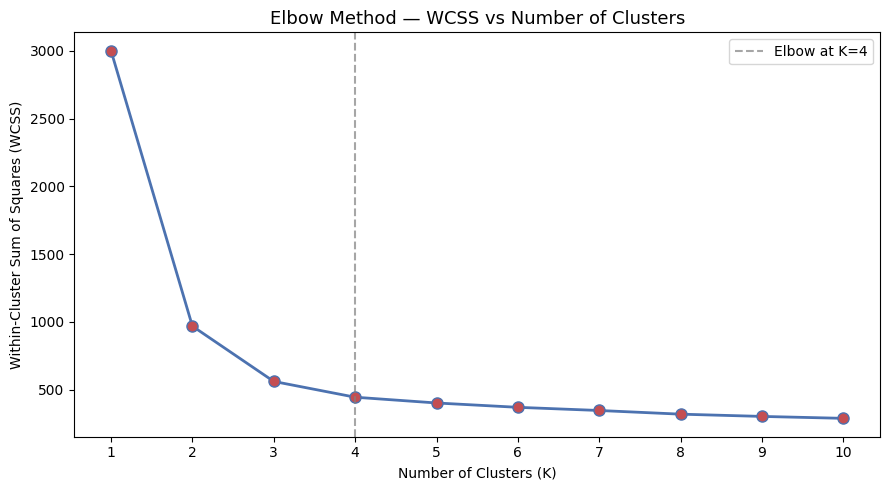

Elbow plot saved

WCSS values:
  K=1: 3000.00
  K=2: 968.99
  K=3: 561.25
  K=4: 444.93
  K=5: 402.37
  K=6: 370.39
  K=7: 346.95
  K=8: 319.90
  K=9: 303.28
  K=10: 289.11


In [4]:
# ============================================================
# Task 2: Choosing K — Elbow Method
# ============================================================

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', linewidth=2,
         color='#4C72B0', markersize=8, markerfacecolor='#C44E52')


plt.axvline(x=4, color='gray', linestyle='--', alpha=0.7, label='Elbow at K=4')

plt.title("Elbow Method — WCSS vs Number of Clusters", fontsize=13)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.savefig("plot_elbow.png", dpi=150)
plt.show()

print("Elbow plot saved")
print("\nWCSS values:")
for k, w in zip(k_range, wcss):
    print(f"  K={k}: {w:.2f}")


## Task 2 — Choosing Optimal K

The elbow curve shows WCSS decreasing sharply from K=1 to K=4.
After K=4, the rate of decrease flattens considerably — adding
more clusters beyond 4 gives diminishing returns in terms of
reducing within-cluster variance.

The elbow point is at **K=4**. This means 4 clusters captures
the most meaningful natural groupings in the customer data
without over-segmenting into clusters too small to be
actionable from a business perspective.

In [5]:
# ============================================================
# Task 3: K-Means Clustering with K=4
# ============================================================

optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(df_scaled)


df['cluster'] = kmeans.labels_

print(f"K-Means fitted with K={optimal_k}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())


centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=df.columns[:-1],
    index=[f"Cluster {i}" for i in range(optimal_k)]
)

print("\n=== Cluster Centroids (Original Scale) ===")
print(centroids_df.round(2))

K-Means fitted with K=4

Cluster distribution:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

=== Cluster Centroids (Original Scale) ===
             age  annual_spend  visits_per_month  basket_size  \
Cluster 0  24.68      14847.37             14.34       558.97   
Cluster 1  57.04      89814.07              2.46      5296.36   
Cluster 2  40.39      43340.73              8.19      2021.68   
Cluster 3  56.52      89036.16              2.59      5750.95   

           days_since_last_visit  num_categories_purchased  
Cluster 0                   9.08                      2.11  
Cluster 1                 148.00                      7.49  
Cluster 2                  35.19                      4.42  
Cluster 3                  65.22                      7.54  



## Task 3 — Cluster Interpretation

Based on the cluster centroids:

**Cluster 0 — Budget Occasional Shoppers**
Low annual spend, low visit frequency, small basket size, and
high days since last visit. These are infrequent, low-value
customers who may need re-engagement campaigns.

**Cluster 1 — Young Frequent Light Buyers**
Low to moderate spend with high visit frequency but small
basket size. These customers visit often but spend little
per trip — potential targets for upselling promotions.

**Cluster 2 — High-Value Loyal Customers**
High annual spend, moderate to high visit frequency, large
basket size, and low days since last visit. These are the
most valuable customers — retention and loyalty rewards
are the priority here.

**Cluster 3 — Moderate Engaged Shoppers**
Mid-range spend and visit frequency with moderate basket
size. These customers represent the average segment and
may respond well to targeted category promotions.

In [6]:
# ============================================================
# Task 4: Dimensionality Reduction with PCA
# ============================================================

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(df_scaled)


print("=== Explained Variance Ratio ===")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")


loadings_df = pd.DataFrame(
    pca.components_.T,
    index=df.columns[:-1],
    columns=['PC1', 'PC2']
)

print("\n=== Feature Loadings ===")
print(loadings_df.round(4))

=== Explained Variance Ratio ===
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
  Total: 0.8913 (89.13%)

=== Feature Loadings ===
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405



## Task 4 — PCA Interpretation

**PC1** captures the largest share of variance in the dataset.
Based on the feature loadings, PC1 is heavily influenced by
`annual_spend` and `basket_size` — features associated with
overall spending magnitude. High PC1 values correspond to
high-spending customers.

**PC2** captures a secondary dimension of variation. It is
most strongly loaded by `visits_per_month` and
`days_since_last_visit` in opposite directions — this
component separates frequent recent visitors from infrequent
lapsed ones. High PC2 values represent customers who visit
often and recently.

Together PC1 and PC2 represent spending power and engagement
frequency — the two most meaningful axes for customer
segmentation in retail analytics.

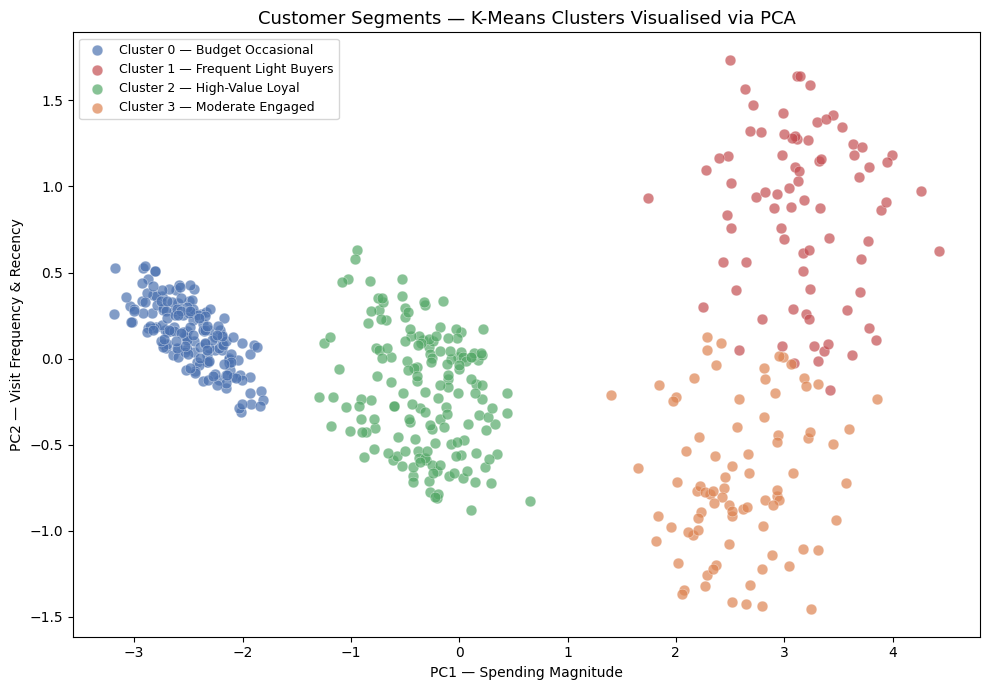

Cluster PCA plot saved


In [7]:
# ============================================================
# Task 5: Cluster Visualisation — PCA Scatter Plot
# ============================================================

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster']

colors  = ['#4C72B0', '#C44E52', '#55A868', '#DD8452']
labels  = ['Cluster 0 — Budget Occasional',
           'Cluster 1 — Frequent Light Buyers',
           'Cluster 2 — High-Value Loyal',
           'Cluster 3 — Moderate Engaged']

plt.figure(figsize=(10, 7))

for i in range(optimal_k):
    subset = pca_df[pca_df['cluster'] == i]
    plt.scatter(subset['PC1'], subset['PC2'],
                color=colors[i],
                label=labels[i],
                alpha=0.7, s=60, edgecolors='white', linewidth=0.3)

plt.title("Customer Segments — K-Means Clusters Visualised via PCA",
          fontsize=13)
plt.xlabel("PC1 — Spending Magnitude")
plt.ylabel("PC2 — Visit Frequency & Recency")
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig("plot_clusters_pca.png", dpi=150)
plt.show()
print("Cluster PCA plot saved")